In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vectorHASH_cont_fns import scaffold_layers, sensory_weights, gridtogrid
from helpers import relu, tanh, softmax, glob_inh, get_mutual_info, get_overlap, noisy_state
from scipy.integrate import solve_ivp
from tqdm import tqdm
from scipy import signal

## Scaffold Only

In [2]:
def scaffold(t, state, Ng, Nh, W_gg, W_hg, W_gh, lambdas, b, tau_g, tau_h, inh_strength=1):
    g = state[:Ng]
    h = state[Ng:]

    dg = (-g + glob_inh(W_gg @ g + W_gh @ h, lambdas, inh_strength)) / tau_g
    dh = (-h + relu(W_hg @ g - b)) / tau_h

    return np.concatenate([dg, dh])

### Testing activation functions

In [3]:
def glob_inh(x, lambdas, inh_strength):
    x1 = x.copy()
    if x.ndim == 1:
        x1 = x[:, None]

    lambdas = np.asarray(lambdas)
    y = np.zeros_like(x1)
    i = 0
    for lam in lambdas:
        size = lam**2
        module = x1[i:i+size, :]
        module_pos = np.where(module > 0, module, 0)
        sq_activity = module_pos*module_pos
        y[i:i+size, :] = sq_activity / (1 + inh_strength * np.sum(sq_activity, axis=0, keepdims=True))
        i += size

    if x.ndim == 1:
        return y[:, 0]
    return y


a = np.random.randn(4)
print(a, a.ndim)
b = softmax(a, [2])
print(b)
print(glob_inh(a, [2], 1))


[0.79228439 1.60396721 0.48486507 0.99396602] 1
[2.97713158e-04 9.97451400e-01 1.37623587e-05 2.23712478e-03]
[0.11574001 0.47436462 0.04334741 0.18216477]


In [13]:
lams = np.array([2,3])          # grid periods
Ng = np.sum(lams*lams)              # number of grid units
patts_total = np.prod(lams*lams)    # total number of patterns possible to store
Nh = 200                            # number of hc units
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
#print(W_gg)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

# testing the weight matrix: grid state should stay at fixed point
g = grid[:, 1]
print(g)
print("0 state:", np.argmax(g[:4]), np.argmax(g[4:]))

for i in range(3):
    print(f"{i+1} state:", np.argmax(g2[:4]), np.argmax(g2[4:]))
print("\n")

for i in range(5):
    g3 = glob_inh(W_gg @ g, lams, 10)
    print(g3)
    print(f"{i+1} state:", np.argmax(g3[:4]), np.argmax(g3[4:]))


[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
0 state: 1 1
1 state: 1 1
2 state: 1 1
3 state: 1 1


[0.         0.09350649 0.         0.         0.         0.09350649
 0.         0.         0.         0.         0.         0.
 0.        ]
1 state: 1 1
[0.         0.09350649 0.         0.         0.         0.09350649
 0.         0.         0.         0.         0.         0.
 0.        ]
2 state: 1 1
[0.         0.09350649 0.         0.         0.         0.09350649
 0.         0.         0.         0.         0.         0.
 0.        ]
3 state: 1 1
[0.         0.09350649 0.         0.         0.         0.09350649
 0.         0.         0.         0.         0.         0.
 0.        ]
4 state: 1 1
[0.         0.09350649 0.         0.         0.         0.09350649
 0.         0.         0.         0.         0.         0.
 0.        ]
5 state: 1 1


### Testing the scaffold

In [4]:
lams = np.array([3, 4, 5]) 
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(20, -3, lams)

grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

initial state: g0 = pattern

In [4]:
# if intial state is a fixed point, should stay at that fixed point
patt = 35
g0 = grid[:, patt]
h0 = hc[:, patt]
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 10, 100))

g_traj = sol.y[:Ng, :]   # shape: (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

np.set_printoptions(precision=3, suppress=True)

print(np.argmax(g_traj[:,-1][:9]), np.argmax(g_traj[:,-1][9:25]), np.argmax(g_traj[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj[:,-1][:9])
print(g_traj[:,-1][9:25])
print(g_traj[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj[:, -1] - h0))  

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, -1])
print("overlap between sensory vectors:", get_overlap(s_recalled, s_actual)) 


8 3 10
original state: 8 3 10
[0.047 0.043 0.044 0.024 0.029 0.025 0.041 0.032 0.714]
[0.001 0.001 0.003 0.936 0.002 0.005 0.009 0.004 0.007 0.005 0.002 0.006
 0.004 0.006 0.006 0.003]
[0.    0.001 0.    0.    0.    0.    0.    0.    0.    0.    0.997 0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.   ]
L2 norm between h's: 3.8904637478460553
overlap between sensory vectors: 0.7933333333333333


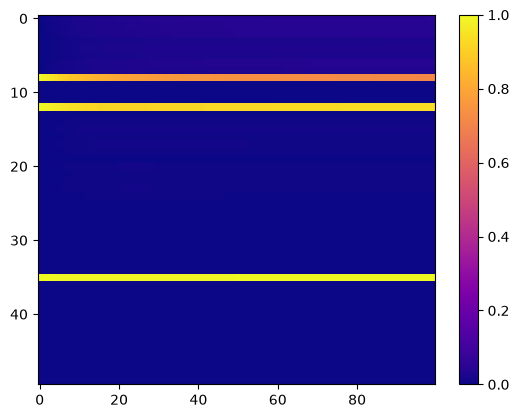

In [5]:
# g0 = pattern, wgg has 20, -3
plt.imshow(g_traj[:, :], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()

initial state: g0 = zero vector

In [31]:
patt = 0
g0, h0 = np.zeros(Ng), hc[:, patt]
#g0, h0 = grid[:, patt], np.zeros(Nh)

state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 100), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500))

g_traj = sol.y[:Ng, :]   # shape: (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

np.set_printoptions(precision=3, suppress=True)

print(np.argmax(g_traj[:,-1][:9]), np.argmax(g_traj[:,-1][9:25]), np.argmax(g_traj[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj[:,-1][:9])
print(g_traj[:,-1][9:25])
print(g_traj[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj[:, -1] - h0))

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, 20])
print("overlap between sensory vectors:", get_overlap(s_recalled, s_actual)) 
print("MI between sensory vectors:", get_mutual_info(s_recalled, s_actual)) 

0 0 0
original state: 0 0 0
[0.415 0.05  0.107 0.032 0.028 0.129 0.119 0.031 0.088]
[0.959 0.003 0.003 0.003 0.005 0.001 0.004 0.002 0.002 0.002 0.001 0.003
 0.004 0.003 0.001 0.002]
[0.998 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.   ]
L2 norm between h's: 6.899668067901997
overlap between sensory vectors: 0.7177777777777777
MI between sensory vectors: 0.4128586688429319


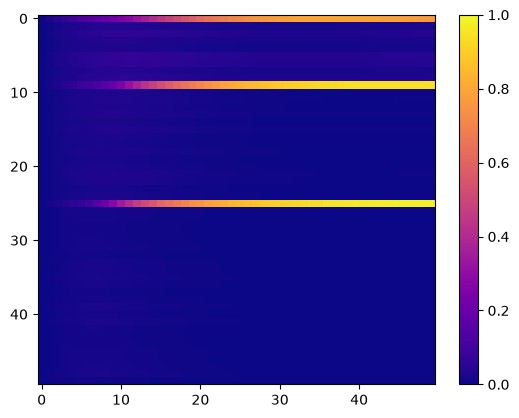

In [27]:
# g0 = zeros, wgg has 20, -3
plt.imshow(g_traj[:, :50], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()

0.6080181569472155


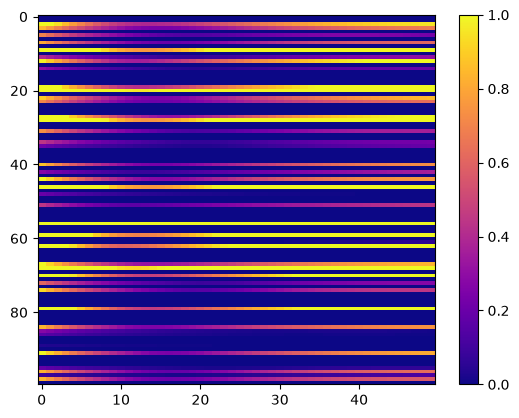

In [28]:
plt.imshow(h_traj[:100, :50], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()
print(get_overlap(h_traj[:,-1], h0))

### Adding noise

In [54]:
patt = 0
g0 = grid[:, patt]
#g0 = np.zeros(Ng)
h0 = noisy_state(hc[:, patt], 2.001)
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 10, 100)
)

g_traj_noisy = sol.y[:Ng, :]
h_traj_noisy = sol.y[Ng:, :]

In [52]:
print(np.argmax(g_traj_noisy[:,-1][:9]), np.argmax(g_traj_noisy[:,-1][9:25]), np.argmax(g_traj_noisy[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj_noisy[:,-1][:9])
print(g_traj_noisy[:,-1][9:25])
print(g_traj_noisy[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj_noisy[:, -1] - h0))  

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj_noisy[:, -1])
print("overlap between sensory vectors:", get_overlap(s_recalled, s_actual)) 

5 0 0
original state: 0 0 0
[0.06  0.036 0.055 0.051 0.054 0.093 0.079 0.022 0.05 ]
[0.366 0.003 0.007 0.016 0.006 0.008 0.005 0.01  0.013 0.013 0.005 0.013
 0.01  0.009 0.007 0.008]
[0.475 0.    0.001 0.001 0.002 0.001 0.001 0.001 0.001 0.    0.001 0.001
 0.001 0.    0.001 0.001 0.001 0.002 0.001 0.001 0.001 0.001 0.001 0.002
 0.   ]
L2 norm between h's: 41.62138798787283
overlap between sensory vectors: 0.0038888888888888888


## Adding waves to scaffold

In [3]:
def scaffold_hwave(t, state, Ng, Nh, W_gg, W_hg, W_gh, lambdas, b, tau_g, tau_h, f, shift, duty, inh_strength=1):
    g = state[:Ng]
    h = state[Ng:]

    theta_h = signal.square(2*np.pi*f*(t - shift), duty=duty)
    dg = (-g + glob_inh(W_gg @ g + theta_h * W_gh @ h, lambdas, inh_strength)) / tau_g
    dh = (-h + relu(W_hg @ g - b)) / tau_h

    return np.concatenate([dg, dh])

In [4]:
lams = np.array([3, 4, 5]) 
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)

grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens[:, :200], hc)

In [7]:
patt = 3
#g0, h0 = np.zeros(Ng), hc[:, patt]
g0, h0 = grid[:, patt], hc[:, patt]
#g0, h0 = grid[:, patt], np.zeros(Nh)

state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 100), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500))

g_traj = sol.y[:Ng, :]   # shape: (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

np.set_printoptions(precision=3, suppress=True)

print(np.argmax(g_traj[:,-1][:9]), np.argmax(g_traj[:,-1][9:25]), np.argmax(g_traj[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj[:,-1][:9])
print(g_traj[:,-1][9:25])
print(g_traj[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj[:, -1] - h0))

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, -1])
print("overlap between sensory vectors:", get_overlap(s_recalled, s_actual)) 
print("MI between sensory vectors:", get_mutual_info(s_recalled, s_actual)) 

8 14 13
original state: 3 3 3
[0.072 0.123 0.047 0.13  0.094 0.057 0.076 0.087 0.297]
[0.098 0.032 0.022 0.081 0.085 0.053 0.033 0.115 0.046 0.057 0.04  0.025
 0.055 0.055 0.144 0.015]
[0.042 0.019 0.043 0.035 0.021 0.042 0.034 0.058 0.02  0.051 0.02  0.012
 0.012 0.103 0.013 0.031 0.029 0.017 0.021 0.046 0.089 0.018 0.063 0.035
 0.026]
L2 norm between h's: 17.722846790111273
overlap between sensory vectors: -0.06944444444444445
MI between sensory vectors: 0.0034815221283692743


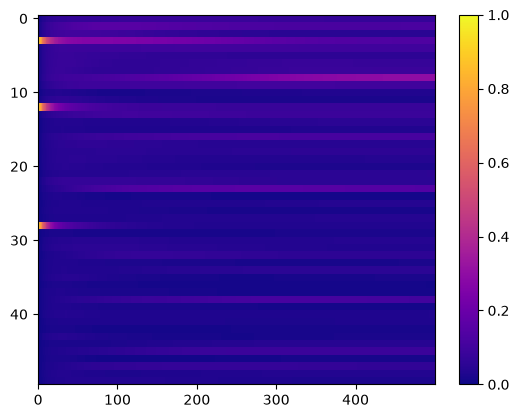

In [8]:
plt.imshow(g_traj[:, :500], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()

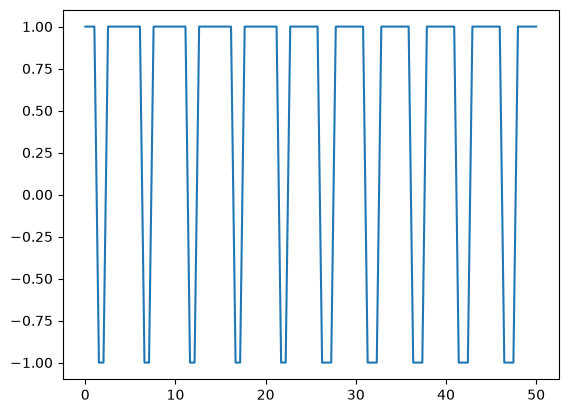

In [76]:
frequency = 1/5                
duty_cycle = 0.75              
phase_degrees = 180             

time_shift = (phase_degrees / 360) * (1/f) 
t = np.linspace(0,50,100)
wave = signal.square(2 * np.pi * frequency * (t - time_shift), duty=duty_cycle)
plt.plot(t, wave)
plt.show()

In [12]:
patt = 76
#g0 = np.zeros(Ng)
g0 = grid[:, patt]
h0 = hc[:, patt]
#h0 = np.zeros(Nh)
state0 = np.concatenate([g0, h0])
f, duty = 1/5, 0.5
shift = (180 / 360) * (1/f)

sol = solve_ivp(
    scaffold_hwave, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0.5, 1.0, 1.0, f, shift, duty),
    method='RK45', t_eval=np.linspace(0, 50, 500))

g_traj2 = sol.y[:Ng, :]
h_traj2 = sol.y[Ng:, :]

np.set_printoptions(precision=10, suppress=True)

print(np.argmax(g_traj2[:,-1][:9]), np.argmax(g_traj2[:,-1][9:25]), np.argmax(g_traj2[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj2[:,-1][:9])
print(g_traj2[:,-1][9:25])
print(g_traj2[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj2[:, -1] - h0))  

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj2[:, -1])
print("overlap between sensory vectors:", get_overlap(s_recalled, s_actual)) 
print("MI between sensory vectors:", get_mutual_info(s_recalled, s_actual)) 

4 12 1
original state: 4 12 1
[0.0000001876 0.000000516  0.0000000792 0.0000002685 0.0000028869
 0.0000001632 0.0000001557 0.0000004279 0.0000002741]
[0.000000088  0.0000000685 0.0000000269 0.0000000835 0.0000002272
 0.0000000462 0.0000000811 0.0000001077 0.0000001102 0.0000000736
 0.0000001527 0.0000000681 0.00000085   0.0000002307 0.000000187
 0.0000000403]
[0.0000000646 0.0000002448 0.000000065  0.0000000447 0.0000000243
 0.0000000722 0.0000000264 0.0000000704 0.0000000334 0.0000000718
 0.0000000668 0.0000000467 0.0000000532 0.0000000549 0.000000061
 0.0000000851 0.0000000282 0.0000000489 0.000000022  0.0000000512
 0.0000000719 0.0000000208 0.0000000571 0.0000000344 0.0000000335]
L2 norm between h's: 18.872087459132615
overlap between sensory vectors: 0.39611111111111114
MI between sensory vectors: 0.11634519787539976


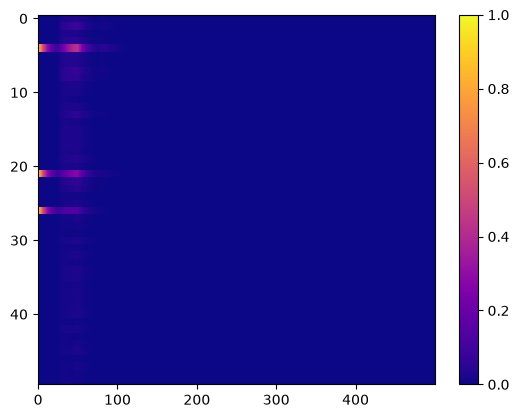

In [13]:
plt.imshow(g_traj2[:, :], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()

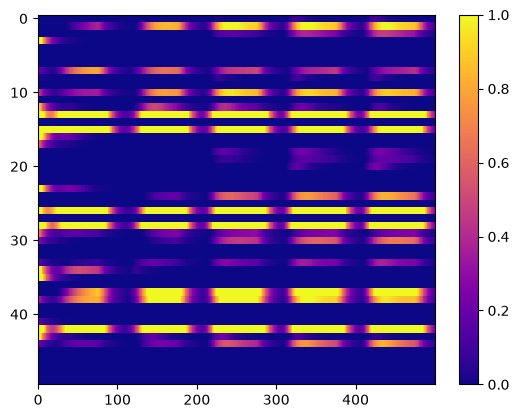

In [30]:
plt.imshow(h_traj[:50, :500], aspect="auto", interpolation="none", vmin=0, vmax=1, cmap="plasma")
plt.colorbar()

## The full model

In [2]:
def vectorhash(t, state, Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lambdas, b, tau_g, tau_h, tau_s, inh=1, beta=10):
    g = state[:Ng]
    h = state[Ng : Ng+Nh]
    s = state[Ng+Nh:]

    dg = (-g + glob_inh(W_gg @ g + 1*W_gh @ h, lambdas, inh)) / tau_g
    dh = (-h + relu(W_hg @ g + W_hs @ s - b)) / tau_h
    ds = (-s + tanh(W_sh @ h, beta)) / tau_s

    return np.concatenate([dg, dh, ds])

lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)         
patts_total = np.prod(lams*lams)
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(20, -3, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0.6)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens[:, :300], hc)

In [13]:
patt = 2
#g0 = grid[:, patt]
g0 = np.zeros(Ng)
#h0 = hc[:, patt]
h0 = np.zeros(Nh)
s0 = sens[:, patt]
#s0 = s0 * np.sign(np.random.uniform(0, 1, s0.shape) - 0.4)
state0 = np.concatenate([g0, h0, s0])

sol2 = solve_ivp(
    vectorhash, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 1.0, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 10, 100)
)

g_traj2 = sol2.y[:Ng, :]
h_traj2 = sol2.y[Ng:Ng+Nh, :]
s_traj2 = sol2.y[Ng+Nh:, :]

In [14]:
np.set_printoptions(precision=3, suppress=True)

print(np.argmax(g_traj2[:,-1][:9]), np.argmax(g_traj2[:,-1][9:25]), np.argmax(g_traj2[:,-1][25:]))
print("original state:", np.argmax(grid[:,patt][:9]), np.argmax(grid[:,patt][9:25]), np.argmax(grid[:,patt][25:]))
print(g_traj2[:,-1][:9])
print(g_traj2[:,-1][9:25])
print(g_traj2[:,-1][25:])

print("L2 norm between h's:", np.linalg.norm(h_traj2[:, -1] - h0)) 

print("L2 norm between s's:", np.linalg.norm(sens[:, patt] - s_traj2[:, -1]))  
print(get_mutual_info(np.sign(s_traj2[:, -1]), sens[:, patt]))
#print(get_mutual_info(np.sign(s0), sens[:, patt]))

2 2 2
original state: 2 2 2
[0.102 0.058 0.388 0.114 0.041 0.126 0.052 0.064 0.054]
[0.01  0.012 0.827 0.007 0.011 0.007 0.016 0.013 0.005 0.008 0.01  0.017
 0.023 0.008 0.012 0.012]
[0.002 0.001 0.972 0.001 0.002 0.    0.001 0.    0.001 0.001 0.004 0.
 0.002 0.002 0.001 0.002 0.    0.001 0.001 0.001 0.    0.001 0.001 0.001
 0.001]
L2 norm between h's: 25.24369020376105
L2 norm between s's: 34.842711991879156
0.5310044064107189


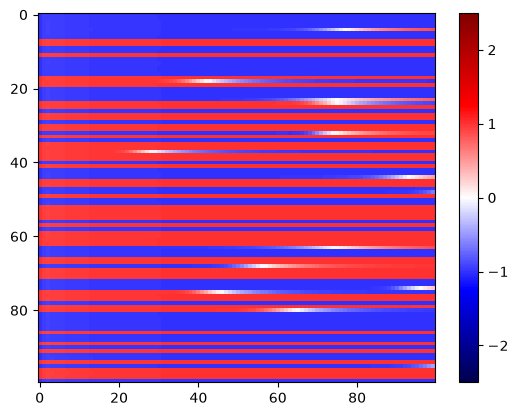

In [15]:
plt.imshow(s_traj2[:100, :], aspect="auto", interpolation="none", vmin=-2.5, vmax=2.5, cmap="seismic")
plt.colorbar()

## Plots

### Fig 2e

In [5]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

mean_hc_norm = np.mean(np.linalg.norm(hc, axis=0))
print(mean_hc_norm.shape)
noise_vals = np.arange(0, 10, 0.5)
runs = 100
correct = np.zeros((runs, len(noise_vals)))
patt = 0
g0 = np.zeros(Ng)
h0 = hc[:,patt] 

for i in range(runs):
    for nidx, noise_val in enumerate((noise_vals)):
        noise = np.random.normal(0, 1, h0.shape) / np.sqrt(Nh)
        h0_noisy = h0 + noise_val*noise*mean_hc_norm
        state0 = np.concatenate([g0, h0_noisy])

        sol = solve_ivp(
                    scaffold, t_span=(0, 10), y0=state0,
                    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 1.0, 1.0),
                    method='RK45', t_eval=np.linspace(0, 10, 100)
                )

        h_10 = sol.y[Ng:, -1]
        s_recalled = np.sign(W_sh @ h_10)
        err = np.linalg.norm(h_10 - h0)
        correct[i, nidx] = err

()


[[12.37625817 12.28985379 12.19945541 ... 14.09697768 13.69873765
  14.33655493]
 [12.37625817 12.20128623 14.14256003 ... 14.51218618 13.90726933
  14.52998094]
 [12.37625817 12.30054375 12.4156025  ... 14.17015738 14.00112428
  14.14753122]
 ...
 [12.37625817 12.30442401 12.30028968 ... 14.16832861 14.12071179
  12.15342533]
 [12.37625817 12.38749461 12.27612297 ... 13.99081669 14.23131163
  13.69100555]
 [12.37625817 12.13745118 12.24695247 ... 14.14848126 14.14630836
  12.89692107]]


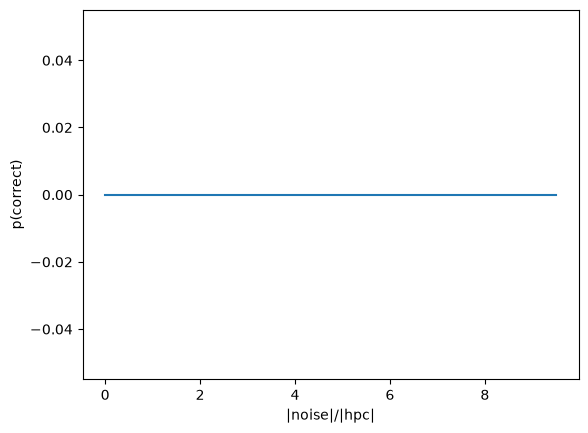

In [ ]:
print(correct)
correct_valid = correct<1e-1
correct_avg = correct_valid.mean(axis=0)

plt.plot(noise_vals, correct_avg);
plt.xlabel(r'|noise|/|hpc|');
plt.ylabel('p(correct)');

### Fig 3f

In [ ]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens[:, :600], hc)

noise_vals = np.arange(0, 0.55, 0.05)
runs = 100
correct = np.zeros((runs, len(noise_vals)))
patt = 0
g0 = np.zeros(Ng)
h0 = np.zeros(Nh)
s0 = sens[:, patt]
state0 = np.concatenate([g0, h0, s0])
sol = solve_ivp(vectorhash, t_span=(0, 10), y0=state0,
                                args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 1.0, 1.0, 1.0),
                                method='RK45', t_eval=np.linspace(0, 10, 100)
                                )
s_actual = sol.y[Ng+Nh:, -1]  

for i in tqdm(range(runs)):
    for nidx, noise_val in enumerate(noise_vals):
        s0_noisy = s0 * np.sign(np.random.uniform(0, 1, s0.shape) - noise_val)
        state0_noisy = np.concatenate([g0, h0, s0_noisy])

        sol_noisy = solve_ivp(vectorhash, t_span=(0, 10), y0=state0_noisy,
                        args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0.5, 1.0, 1.0, 1.0),
                        method='RK45', t_eval=np.linspace(0, 10, 100)
                        )     
        s_out = sol_noisy.y[Ng+Nh:, -1]
        err = np.linalg.norm(s_out - s_actual)
        correct[i, nidx] = err

100%|██████████| 100/100 [19:38<00:00, 11.79s/it]


54.58849227076531
[[49.828 48.629 47.562 ... 86.253 84.878 82.554]
 [49.828 48.743 49.77  ... 51.594 85.572 82.963]
 [49.828 47.814 46.572 ... 82.476 81.372 83.59 ]
 ...
 [49.828 49.755 50.434 ... 85.722 78.405 82.75 ]
 [49.828 48.129 50.413 ... 46.793 82.88  81.071]
 [49.828 51.449 50.048 ... 76.188 82.004 81.2  ]]


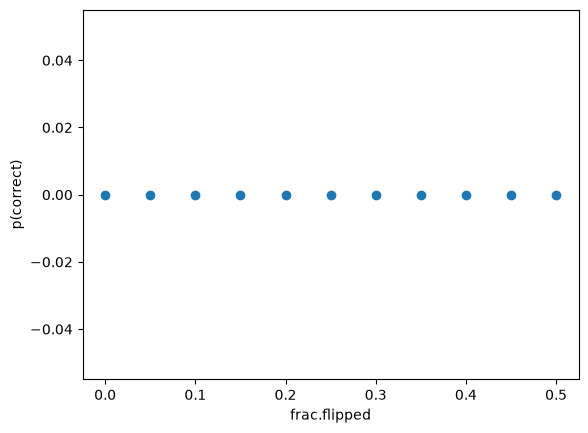

In [21]:
print(np.linalg.norm(s_actual - s0))
print(correct)
correct_valid = correct<5
correct_avg = correct_valid.mean(axis=0)
plt.scatter(noise_vals, correct_avg);
plt.xlabel(r'frac.flipped');
plt.ylabel('p(correct)');

In [ ]:
lams = np.array([3,4,5])
Ng = np.sum(lams*lams)             
patts_total = np.prod(lams*lams)    
Nh, Ns = 400, patts_total                        

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)
sens_patterns = np.sign(np.random.randn(Ns, patts_total))
pattern_range = np.arange(1, patts_total+1, 100)  # list of Npatts to test memory on
plot_list = []

for N_patts in pattern_range:
    sens = sens_patterns[:, :N_patts]
    W_hs, W_sh = sensory_weights(sens, hc)
    

## Adding waves

In [33]:
def square_theta(t, period, phase, duty=0.5):
    tt = (t - phase) % period
    return 1.0 if tt < duty * period else 0.0


def vectorhash_sqwave(t, state, Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lambdas, b, tau_g, tau_h, tau_s,
                     period_g, duty_g, phase_g,
                     period_s, duty_s, phase_s, beta=10):
    g = state[:Ng]
    h = state[Ng : Ng+Nh]
    s = state[Ng+Nh:]

    theta_g = square_theta(t, period_g, phase_g, duty_g)
    theta_s = square_theta(t, period_s, phase_s, duty_s)

    dg = (-g + softmax(W_gg @ g + 1*W_gh @ h, lambdas, beta)) / tau_g
    dh = (-h + relu(theta_g * W_hg @ g + theta_s * W_hs @ s - b)) / tau_h
    ds = (-s + tanh(W_sh @ h, beta)) / tau_s

    return np.concatenate([dg, dh, ds])

lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)         
patts_total = np.prod(lams*lams)
Nh = 400                            
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, 200))
W_hs, W_sh = sensory_weights(sens, hc)

patt = 26
#g0 = grid[:, patt]
g0 = np.zeros(Ng)
#h0 = hc[:, patt]
h0 = np.zeros(Nh)
s0 = sens[:, patt]
state0 = np.concatenate([g0, h0, s0])

period_g, duty_g, phase_g = 0.01, 0.5, 0.0
period_s, duty_s, phase_s = 0.01, 0.5, 0.005

sol2 = solve_ivp(
    vectorhash_sqwave, t_span=(0, 10), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 0.01, 0.01, 0.01,
          period_g, duty_g, phase_g,
          period_s, duty_s, phase_s),
    method='RK45', t_eval=np.linspace(0, 5, 500)) #max_step=min(period_g, period_s)*duty_g/5)

g_traj2 = sol2.y[:Ng, :]   
h_traj2 = sol2.y[Ng:Ng+Nh, :]
s_traj2 = sol2.y[Ng+Nh:, :]

print(np.allclose(g_traj2[:, -1],grid[:,patt]))
#print(g_traj2[:, -1],grid[:,patt])
print(np.allclose(h0, h_traj2[:, -1]))
print(get_mutual_info(s_traj2[:, -1], sens[:, patt]))

/tmp/ipykernel_16528/7928383.py:33: RuntimeWarning: overflow encountered in exp
  exp = np.exp(beta * module)
/tmp/ipykernel_16528/7928383.py:34: RuntimeWarning: invalid value encountered in divide
  y[i:i+size, :] = exp / np.sum(exp, axis=0, keepdims=True)


True
False
1.0000194152982265
